We import MicroMagnetic and use double float precision in the simulation

In [1]:
using MicroMagnetic
using CairoMakie

In this example, the studied system is a round nanodisk. Since we are using finite different method,
we create a FDMesh with dimensions 200nm x 200nm x 20 nm.

In [2]:
mesh = FDMesh(; dx=2e-9, dy=2e-9, dz=5e-9, nx=100, ny=100, nz=4);

Create a cylindrical shape with a diameter of 100 nm

In [3]:
geo = Cylinder(; radius=100e-9);

To start the simulation, we need to give an initial state.
Here we use a function to give the initial state. The function should take six parameters `(i,j,k,dx,dy,dz)`.

In [4]:
function init_fun(x, y, z)
    r = sqrt(x^2 + y^2)
    if r < 20e-9
        return (0, 0, 1)
    end
    return (y / r, -x / r, 0)
end

init_fun (generic function with 1 method)

We define the

In [5]:
args = (
    task = "Relax",
    mesh = mesh,
    shape = geo,
    Ms = 8e5,
    A = 1.3e-11,
    demag = true,
    m0 = init_fun,
    stopping_dmdt = 0.01
);

sim = sim_with(args);

[ Info: MicroSim has been created.
[ Info: Exchange has been added.
[ Info: Running Driver : MicroMagnetic.EnergyMinimization{Float64}.
[ Info: max_dmdt is less than stopping_dmdt=0.01 @steps=127, Done!


We plot the magnetization distribution using the plot_m function

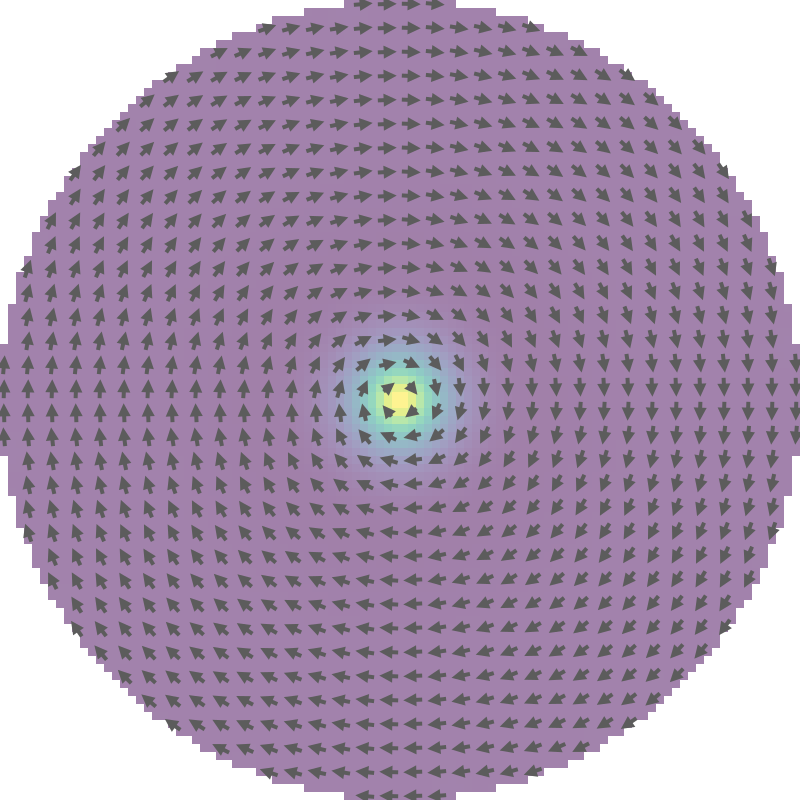

In [6]:
plot_m(sim; figsize=(400, 400), arrows=(30, 30))

we save the vtk as well

In [7]:
save_vtk(sim, "vortex")

1-element Vector{String}:
 "vortex.vts"

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*